In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.chdir(os.path.dirname(os.path.abspath("__file__")) + "/..")
print("Working directory:", os.getcwd())

Working directory: C:\Users\user\Desktop\risk_dashboard


In [2]:
hist = pd.read_csv("data/processed/historical_var.csv", index_col=0)
para = pd.read_csv("data/processed/parametric_var.csv", index_col=0)
mc = pd.read_csv("data/processed/monte_carlo_var.csv", index_col=0)

print("All 3 VaR results loaded!")

All 3 VaR results loaded!


In [3]:
comparison = pd.DataFrame({
    "Historical_95%":  hist["VaR_95%"],
    "Parametric_95%":  para["VaR_95%"],
    "MonteCarlo_95%":  mc["VaR_95%"],
    "Historical_99%":  hist["VaR_99%"],
    "Parametric_99%":  para["VaR_99%"],
    "MonteCarlo_99%":  mc["VaR_99%"],
})

# Which method is most conservative (lowest number = biggest loss predicted)
comparison["Most_Conservative"] = comparison[
    ["Historical_95%", "Parametric_95%", "MonteCarlo_95%"]
].idxmin(axis=1)

comparison.to_csv("data/processed/var_comparison.csv")

print("=" * 70)
print("   VAR COMPARISON TABLE - ALL 3 METHODS")
print("=" * 70)
print(comparison)

   VAR COMPARISON TABLE - ALL 3 METHODS
      Historical_95%  Parametric_95%  MonteCarlo_95%  Historical_99%  \
AAPL         -0.0276         -0.0276         -0.0277         -0.0456   
CVX          -0.0261         -0.0263         -0.0257         -0.0469   
EL           -0.0376         -0.0468         -0.0460         -0.0631   
GS           -0.0241         -0.0268         -0.0269         -0.0433   
HLI          -0.0263         -0.0275         -0.0277         -0.0405   
JNJ          -0.0160         -0.0170         -0.0173         -0.0256   
JPM          -0.0251         -0.0252         -0.0248         -0.0438   
KO           -0.0153         -0.0160         -0.0160         -0.0251   
MCD          -0.0169         -0.0178         -0.0180         -0.0299   
META         -0.0421         -0.0505         -0.0505         -0.0702   
MRK          -0.0187         -0.0204         -0.0203         -0.0302   
PLTR         -0.0635         -0.0685         -0.0685         -0.0871   
ULTA         -0.0325    

In [4]:
print("=" * 70)
print("   KEY FINDINGS")
print("=" * 70)

for ticker in comparison.index:
    h = comparison.loc[ticker, "Historical_95%"]
    p = comparison.loc[ticker, "Parametric_95%"]
    m = comparison.loc[ticker, "MonteCarlo_95%"]
    most_cons = comparison.loc[ticker, "Most_Conservative"]
    
    print(f"\n{ticker}:")
    print(f"  Historical:  {h*100:.2f}%")
    print(f"  Parametric:  {p*100:.2f}%")
    print(f"  Monte Carlo: {m*100:.2f}%")
    print(f"  Most Conservative: {most_cons}")

   KEY FINDINGS

AAPL:
  Historical:  -2.76%
  Parametric:  -2.76%
  Monte Carlo: -2.77%
  Most Conservative: MonteCarlo_95%

CVX:
  Historical:  -2.61%
  Parametric:  -2.63%
  Monte Carlo: -2.57%
  Most Conservative: Parametric_95%

EL:
  Historical:  -3.76%
  Parametric:  -4.68%
  Monte Carlo: -4.60%
  Most Conservative: Parametric_95%

GS:
  Historical:  -2.41%
  Parametric:  -2.68%
  Monte Carlo: -2.69%
  Most Conservative: MonteCarlo_95%

HLI:
  Historical:  -2.63%
  Parametric:  -2.75%
  Monte Carlo: -2.77%
  Most Conservative: MonteCarlo_95%

JNJ:
  Historical:  -1.60%
  Parametric:  -1.70%
  Monte Carlo: -1.73%
  Most Conservative: MonteCarlo_95%

JPM:
  Historical:  -2.51%
  Parametric:  -2.52%
  Monte Carlo: -2.48%
  Most Conservative: Parametric_95%

KO:
  Historical:  -1.53%
  Parametric:  -1.60%
  Monte Carlo: -1.60%
  Most Conservative: Parametric_95%

MCD:
  Historical:  -1.69%
  Parametric:  -1.78%
  Monte Carlo: -1.80%
  Most Conservative: MonteCarlo_95%

META:
  Histo

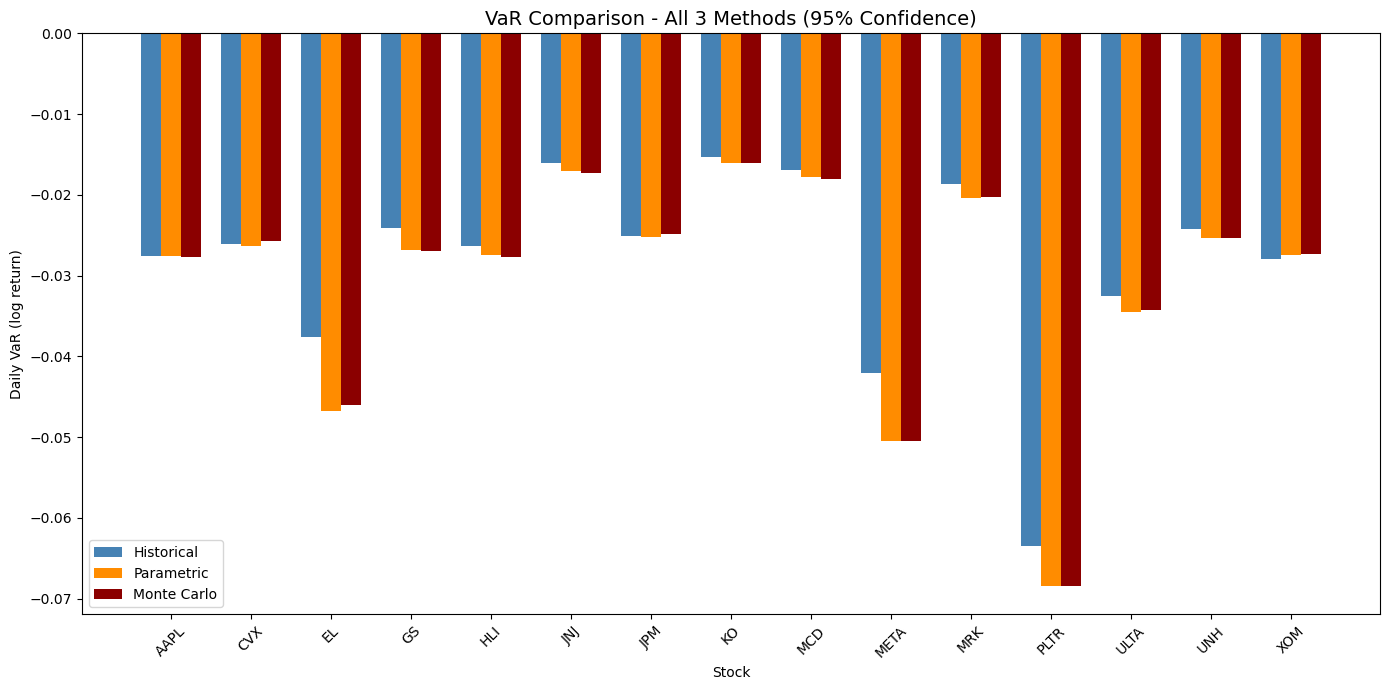

Chart saved!


In [5]:
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(comparison.index))
width = 0.25

ax.bar(x - width, comparison["Historical_95%"], width, 
       label="Historical", color="steelblue")
ax.bar(x,          comparison["Parametric_95%"], width, 
       label="Parametric", color="darkorange")
ax.bar(x + width,  comparison["MonteCarlo_95%"], width, 
       label="Monte Carlo", color="darkred")

ax.set_title("VaR Comparison - All 3 Methods (95% Confidence)", fontsize=14)
ax.set_xlabel("Stock")
ax.set_ylabel("Daily VaR (log return)")
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig("reports/var_comparison_chart.png")
plt.show()
print("Chart saved!")

In [6]:
sectors = {
    "Financials":       ["JPM", "GS", "HLI"],
    "Tech":             ["AAPL", "PLTR", "META"],
    "Healthcare":       ["JNJ", "MRK", "UNH"],
    "Consumer Staples": ["MCD", "KO"],
    "Beauty":           ["EL", "ULTA"],
    "Energy":           ["XOM", "CVX"]
}

print("=" * 60)
print("   SECTOR AVERAGE VAR (95%) - ALL 3 METHODS")
print("=" * 60)

for sector, tickers in sectors.items():
    h_avg = comparison.loc[tickers, "Historical_95%"].mean()
    p_avg = comparison.loc[tickers, "Parametric_95%"].mean()
    m_avg = comparison.loc[tickers, "MonteCarlo_95%"].mean()
    print(f"\n{sector}:")
    print(f"  Historical:  {h_avg*100:.2f}%")
    print(f"  Parametric:  {p_avg*100:.2f}%")
    print(f"  Monte Carlo: {m_avg*100:.2f}%")

   SECTOR AVERAGE VAR (95%) - ALL 3 METHODS

Financials:
  Historical:  -2.52%
  Parametric:  -2.65%
  Monte Carlo: -2.65%

Tech:
  Historical:  -4.44%
  Parametric:  -4.89%
  Monte Carlo: -4.89%

Healthcare:
  Historical:  -1.96%
  Parametric:  -2.09%
  Monte Carlo: -2.10%

Consumer Staples:
  Historical:  -1.61%
  Parametric:  -1.69%
  Monte Carlo: -1.70%

Beauty:
  Historical:  -3.50%
  Parametric:  -4.07%
  Monte Carlo: -4.01%

Energy:
  Historical:  -2.71%
  Parametric:  -2.69%
  Monte Carlo: -2.65%


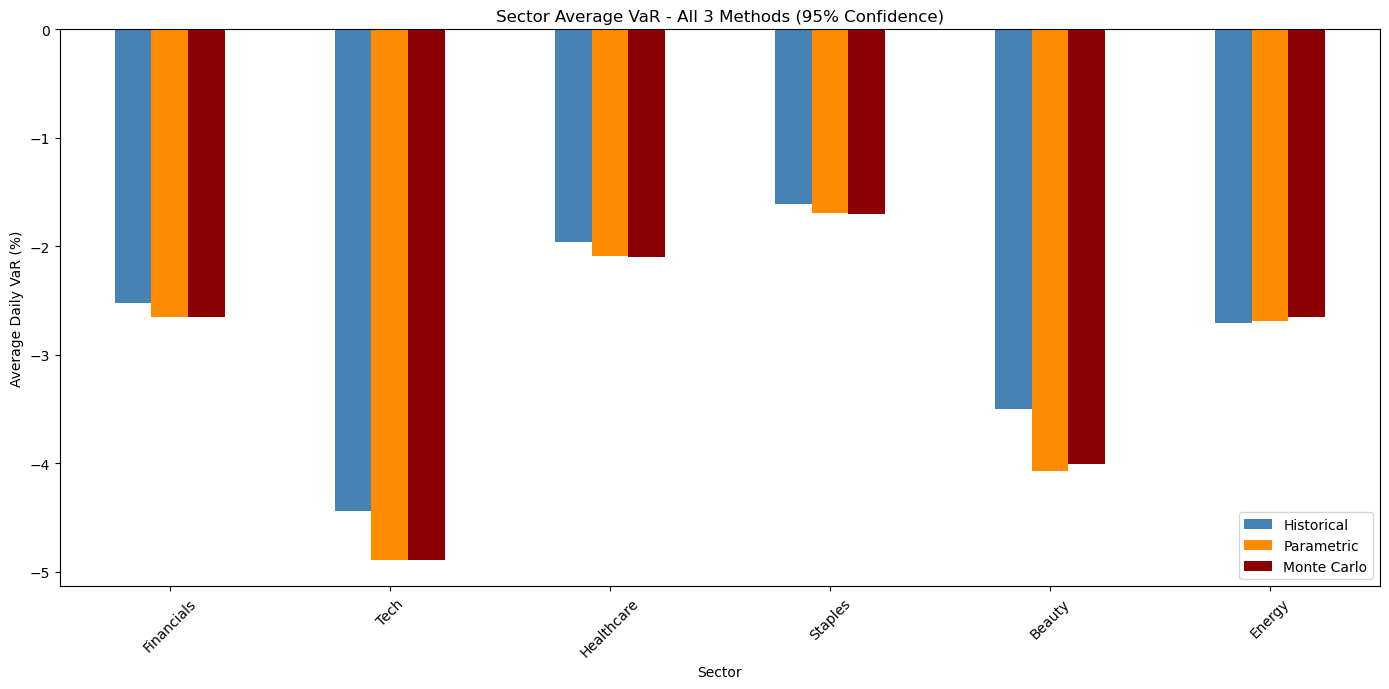

Sector chart saved! ✅


In [7]:
# Sector comparison chart
sectors_df = pd.DataFrame({
    "Historical":  [-2.52, -4.44, -1.96, -1.61, -3.50, -2.71],
    "Parametric":  [-2.65, -4.89, -2.09, -1.69, -4.07, -2.69],
    "Monte Carlo": [-2.65, -4.89, -2.10, -1.70, -4.01, -2.65]
}, index=["Financials", "Tech", "Healthcare", "Staples", "Beauty", "Energy"])

sectors_df.plot(
    kind="bar",
    figsize=(14, 7),
    color=["steelblue", "darkorange", "darkred"],
    title="Sector Average VaR - All 3 Methods (95% Confidence)"
)
plt.ylabel("Average Daily VaR (%)")
plt.xlabel("Sector")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("reports/sector_var_comparison.png")
plt.show()
print("Sector chart saved! ✅")

In [8]:
print("\n")
print("╔══════════════════════════════════════════════════════════════════╗")
print("║           REAL-TIME RISK DASHBOARD - VAR ANALYSIS REPORT        ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║  Methods: Historical | Parametric | Monte Carlo                 ║")
print("║  Confidence Level: 95%                                          ║")
print("║  Data Period: 2022-2025 | 15 Stocks | 6 Sectors                ║")
print("╚══════════════════════════════════════════════════════════════════╝")

print("\n📊 SECTOR RISK OVERVIEW")
print("─" * 60)
sector_data = [
    ("🔴 Tech",              "AAPL, PLTR, META",     -4.44, "Most Risky"),
    ("🟠 Beauty",            "EL, ULTA",              -3.50, "High Risk"),
    ("🟡 Energy",            "XOM, CVX",              -2.71, "Medium Risk"),
    ("🟡 Financials",        "JPM, GS, HLI",          -2.52, "Medium Risk"),
    ("🟢 Healthcare",        "JNJ, MRK, UNH",         -1.96, "Low Risk"),
    ("🟢 Consumer Staples",  "MCD, KO",               -1.61, "Safest"),
]
for sector, stocks, var, label in sector_data:
    bar = "█" * int(abs(var) * 8)
    print(f"{sector:<22} {var:>6.2f}%  {bar:<40} {label}")

print("\n\n🏆 TOP 5 RISKIEST STOCKS")
print("─" * 60)
risky = [
    ("1st", "PLTR", "Tech",       -6.35, -8.71),
    ("2nd", "META", "Tech",       -4.21, -7.02),
    ("3rd", "EL",   "Beauty",     -3.76, -6.31),
    ("4th", "ULTA", "Beauty",     -3.25, -4.72),
    ("5th", "XOM",  "Energy",     -2.80, -4.44),
]
print(f"{'Rank':<6} {'Stock':<8} {'Sector':<12} {'VaR 95%':>10} {'VaR 99%':>10}")
print("─" * 60)
for rank, stock, sector, v95, v99 in risky:
    print(f"{rank:<6} {stock:<8} {sector:<12} {v95:>9.2f}%  {v99:>9.2f}%")

print("\n\n🛡️  TOP 5 SAFEST STOCKS")
print("─" * 60)
safe = [
    ("1st", "KO",  "Staples",    -1.53, -2.51),
    ("2nd", "MCD", "Staples",    -1.69, -2.99),
    ("3rd", "JNJ", "Healthcare", -1.60, -2.56),
    ("4th", "MRK", "Healthcare", -1.87, -3.02),
    ("5th", "UNH", "Healthcare", -2.42, -4.35),
]
print(f"{'Rank':<6} {'Stock':<8} {'Sector':<12} {'VaR 95%':>10} {'VaR 99%':>10}")
print("─" * 60)
for rank, stock, sector, v95, v99 in safe:
    print(f"{rank:<6} {stock:<8} {sector:<12} {v95:>9.2f}%  {v99:>9.2f}%")

print("\n\n🔍 METHOD COMPARISON INSIGHTS")
print("─" * 60)
print("✅ All 3 methods are CONSISTENT → models are reliable")
print("✅ Parametric & Monte Carlo slightly more conservative than Historical")
print("✅ Historical uses real past data → lower estimates")
print("✅ Parametric & MC consider more scenarios → higher estimates")
print("✅ Difference between methods is small → good sign!")

print("\n\n💡 KEY TAKEAWAYS FOR INVESTORS")
print("─" * 60)
print("→ Tech sector carries the HIGHEST daily risk (-4.44% avg)")
print("→ Consumer Staples is the SAFEST sector (-1.61% avg)")
print("→ PLTR alone can lose 6.35% in a single day at 95% confidence")
print("→ KO (Coca-Cola) is most stable - max loss only 1.53% per day")
print("→ Diversifying across sectors significantly reduces overall risk")
print("\n" + "═" * 66)
print("  Report generated by: Real-Time Risk Dashboard | AQM Project")
print("═" * 66)



╔══════════════════════════════════════════════════════════════════╗
║           REAL-TIME RISK DASHBOARD - VAR ANALYSIS REPORT        ║
╠══════════════════════════════════════════════════════════════════╣
║  Methods: Historical | Parametric | Monte Carlo                 ║
║  Confidence Level: 95%                                          ║
║  Data Period: 2022-2025 | 15 Stocks | 6 Sectors                ║
╚══════════════════════════════════════════════════════════════════╝

📊 SECTOR RISK OVERVIEW
────────────────────────────────────────────────────────────
🔴 Tech                  -4.44%  ███████████████████████████████████      Most Risky
🟠 Beauty                -3.50%  ████████████████████████████             High Risk
🟡 Energy                -2.71%  █████████████████████                    Medium Risk
🟡 Financials            -2.52%  ████████████████████                     Medium Risk
🟢 Healthcare            -1.96%  ███████████████                          Low Risk
🟢 Consumer Stapl

In [9]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


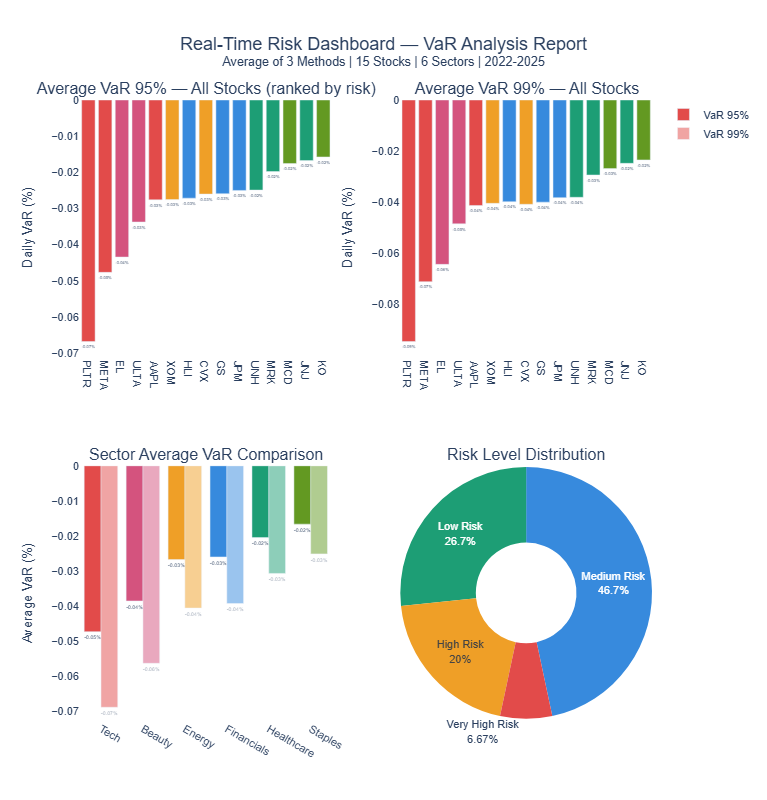

Saved to reports/var_dashboard.html ✅


In [13]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load real results from all 3 methods
hist = pd.read_csv("data/processed/historical_var.csv", index_col=0)
para = pd.read_csv("data/processed/parametric_var.csv", index_col=0)
mc   = pd.read_csv("data/processed/monte_carlo_var.csv", index_col=0)

# Average of all 3 methods
avg_95 = ((hist["VaR_95%"] + para["VaR_95%"] + mc["VaR_95%"]) / 3).sort_values()
avg_99 = ((hist["VaR_99%"] + para["VaR_99%"] + mc["VaR_99%"]) / 3)[avg_95.index]

stocks = avg_95.index.tolist()
var_95 = avg_95.values.tolist()
var_99 = avg_99.values.tolist()

sectors_map = {
    "JPM": "Financials", "GS": "Financials", "HLI": "Financials",
    "AAPL": "Tech",      "PLTR": "Tech",      "META": "Tech",
    "JNJ": "Healthcare", "MRK": "Healthcare", "UNH": "Healthcare",
    "MCD": "Staples",    "KO": "Staples",
    "EL": "Beauty",      "ULTA": "Beauty",
    "XOM": "Energy",     "CVX": "Energy"
}

colors_map = {
    'Tech':        '#E24B4A',
    'Beauty':      '#D4537E',
    'Energy':      '#EF9F27',
    'Financials':  '#378ADD',
    'Healthcare':  '#1D9E75',
    'Staples':     '#639922'
}

sectors    = [sectors_map[s] for s in stocks]
bar_colors = [colors_map[s] for s in sectors]

# Sector averages from real data
sector_names = ['Tech', 'Beauty', 'Energy', 'Financials', 'Healthcare', 'Staples']
sector_95, sector_99 = [], []
for sec in sector_names:
    tickers = [t for t, s in sectors_map.items() if s == sec]
    sector_95.append(avg_95[tickers].mean())
    sector_99.append(avg_99[tickers].mean())

sector_colors = [colors_map[s] for s in sector_names]

# Risk level counts from real data
very_high = sum(1 for v in var_95 if v < -0.05)
high      = sum(1 for v in var_95 if -0.05 <= v < -0.03)
medium    = sum(1 for v in var_95 if -0.03 <= v < -0.02)
low       = sum(1 for v in var_95 if v >= -0.02)

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Average VaR 95% — All Stocks (ranked by risk)",
        "Average VaR 99% — All Stocks",
        "Sector Average VaR Comparison",
        "Risk Level Distribution"
    ),
    specs=[
        [{"type": "xy"},  {"type": "xy"}],
        [{"type": "xy"},  {"type": "pie"}]
    ],
    vertical_spacing=0.18,
    horizontal_spacing=0.12
)

# Chart 1 — VaR 95%
fig.add_trace(go.Bar(
    x=stocks, y=var_95,
    marker_color=bar_colors,
    text=[f"{v:.2f}%" for v in var_95],
    textposition="outside",
    showlegend=False
), row=1, col=1)

# Chart 2 — VaR 99%
fig.add_trace(go.Bar(
    x=stocks, y=var_99,
    marker_color=bar_colors,
    text=[f"{v:.2f}%" for v in var_99],
    textposition="outside",
    showlegend=False
), row=1, col=2)

# Chart 3 — Sector comparison
fig.add_trace(go.Bar(
    x=sector_names, y=sector_95,
    name="VaR 95%",
    marker_color=sector_colors,
    text=[f"{v:.2f}%" for v in sector_95],
    textposition="outside",
    showlegend=True
), row=2, col=1)

fig.add_trace(go.Bar(
    x=sector_names, y=sector_99,
    name="VaR 99%",
    marker_color=sector_colors,
    opacity=0.5,
    text=[f"{v:.2f}%" for v in sector_99],
    textposition="outside",
    showlegend=True
), row=2, col=1)

# Chart 4 — Risk pie (real counts)
fig.add_trace(go.Pie(
    labels=["Very High Risk", "High Risk", "Medium Risk", "Low Risk"],
    values=[very_high, high, medium, low],
    marker_colors=['#E24B4A', '#EF9F27', '#378ADD', '#1D9E75'],
    hole=0.4,
    textinfo="label+percent",
    showlegend=False
), row=2, col=2)

fig.update_layout(
    title={
        'text': "Real-Time Risk Dashboard — VaR Analysis Report<br>"
                "<sup>Average of 3 Methods | 15 Stocks | 6 Sectors | 2022-2025</sup>",
        'x': 0.5,
        'font': {'size': 18}
    },
    height=800,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=11),
)

fig.update_yaxes(title_text="Daily VaR (%)", row=1, col=1)
fig.update_yaxes(title_text="Daily VaR (%)", row=1, col=2)
fig.update_yaxes(title_text="Average VaR (%)", row=2, col=1)

fig.write_html("reports/var_dashboard.html")
fig.show()
print("Saved to reports/var_dashboard.html ✅")